<a href="https://colab.research.google.com/github/karegapauline/Health-Environment-Data-Linking/blob/main/flood_dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Recent flood assement crisis dashboard Kenya
There were recent flash floods in Kenya that caused multiple disasters. The aim of this dashboard is to present the regions most hardly hit by floods. A visual history of the floods and regions most hit, and a predicion of the same with available datasets.  

### Data sources
Getting very recent data is a bit tough. We obtained historical data from the em-dat platform. It contained data about the type of floods, statistics about the imoact in terms of injuries, death, and property damage, thus a good source of data. The downfall with the data is the missing information for some of the data sets, and that it is not very up to date.

Our stratefy to add more data is to additionally get data from social media and news feeds.  

In [ ]:
## Install libraries
#!pip install geopandas

In [ ]:
## Get flood data: em-data downloadable as an excel file. very small dataset.
import pandas as pd
import geopandas as gpd
em_dat_info = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/public_emdat_custom_request_2026-03-09_f4e4b027-2232-4189-bd81-98eb4cbefb48.xlsx")
em_dat_info

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,...,"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,GADM Admin Units,Entry Date,Last Update
0,2002-0265-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,57.341840,"[{""adm2_code"":51334,""adm2_name"":""Kirinyaga""},{...",NaN,2005-09-22,2023-09-25
1,2018-0116-KEN,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,80.049596,"[{""adm1_code"":51328,""adm1_name"":""Nairobi""}]","[{""gid_1"":""KEN.30_1"",""migration_date"":""2025-12...",2018-04-16,2025-12-20
2,2003-0204-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,58.643553,"[{""adm2_code"":51369,""adm2_name"":""Kisumu""},{""ad...",NaN,2004-08-09,2023-09-25
3,2003-0729-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,58.643553,"[{""adm2_code"":51369,""adm2_name"":""Kisumu""}]",NaN,2004-02-26,2023-09-25
4,2005-0526-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,62.256479,"[{""adm2_code"":51396,""adm2_name"":""Busia""}]",NaN,2005-09-13,2023-09-25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2009-0597-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,GLIDE:FL-2010-000003,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,68.391643,"[{""adm2_code"":51333,""adm2_name"":""Kiambu""},{""ad...","[{""gid_2"":""KEN.1.1_1"",""migration_date"":""2025-1...",2011-03-15,2025-12-20
57,2008-0482-KEN,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,68.635672,"[{""adm2_code"":51363,""adm2_name"":""Mandera""}]","[{""gid_2"":""KEN.24.1_1"",""migration_date"":""2025-...",2008-10-22,2025-12-20
58,2008-0260-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,GLIDE:FF-2008-000092|GLIDE:FL-2008-000092,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,68.635672,"[{""adm2_code"":51346,""adm2_name"":""Tana River""}]","[{""gid_2"":""KEN.40.1_1"",""migration_date"":""2025-...",2008-08-24,2025-12-20
59,2006-0587-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,KEN,...,NaN,NaN,NaN,NaN,NaN,64.264832,"[{""adm2_code"":51341,""adm2_name"":""Kwale""},{""adm...","[{""gid_2"":""KEN.19.1_1"",""migration_date"":""2025-...",2007-01-07,2025-12-20


In [ ]:
em_dat_info.columns

Index(['DisNo.', 'Historic', 'Classification Key', 'Disaster Group',
       'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype',
       'External IDs', 'Event Name', 'ISO', 'Country', 'Subregion', 'Region',
       'Location', 'Origin', 'Associated Types', 'OFDA/BHA Response', 'Appeal',
       'Declaration', 'AID Contribution ('000 US$)', 'Magnitude',
       'Magnitude Scale', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless',
       'Total Affected', 'Reconstruction Costs ('000 US$)',
       'Reconstruction Costs, Adjusted ('000 US$)',
       'Insured Damage ('000 US$)', 'Insured Damage, Adjusted ('000 US$)',
       'Total Damage ('000 US$)', 'Total Damage, Adjusted ('000 US$)', 'CPI',
       'Admin Units', 'GADM Admin Units', 'Entry Date', 'Last Update'],
      dtype='object')

In [ ]:
df = em_dat_info[['DisNo.', 'Historic', 'Classification Key', 'Disaster Group', 'Disaster Subgroup', 'Disaster Type', 'Disaster Subtype', 'Latitude', 'Longitude', 'River Basin', 'Start Year',
       'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day',
       'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', 'Total Affected', 'CPI','Entry Date', 'Last Update']].copy()
df.columns
df.describe()
df.dtypes

,0
DisNo.,object
Historic,object
Classification Key,object
Disaster Group,object
Disaster Subgroup,object
Disaster Type,object
Disaster Subtype,object
Latitude,float64
Longitude,float64
River Basin,object


In [ ]:
# Create a copy to avoid SettingWithCopyWarning
df_copy = df.copy()

# Fill NaN values in Month and Day with 1, convert to int
df_copy.loc[:, 'Start Month'] = df_copy['Start Month'].fillna(1).astype(int)
df_copy.loc[:, 'Start Day'] = df_copy['Start Day'].fillna(1).astype(int)
df_copy.loc[:, 'End Month'] = df_copy['End Month'].fillna(1).astype(int)
df_copy.loc[:, 'End Day'] = df_copy['End Day'].fillna(1).astype(int)

# Convert Year columns to int. Since previous output showed 0 NaNs for years, this should be safe.
df_copy.loc[:, 'Start Year'] = df_copy['Start Year'].astype(int)
df_copy.loc[:, 'End Year'] = df_copy['End Year'].astype(int)

# Create date strings directly from the integer components, ensuring zero-padding for month/day
# Explicitly cast Year, Month, and Day to int again within the f-string to prevent formatting errors
df_copy.loc[:, 'Start Date String'] = df_copy.apply(
    lambda row: f"{int(row['Start Year'])}-{int(row['Start Month']):02d}-{int(row['Start Day']):02d}",
    axis=1
)
df_copy.loc[:, 'End Date String'] = df_copy.apply(
    lambda row: f"{int(row['End Year'])}-{int(row['End Month']):02d}-{int(row['End Day']):02d}",
    axis=1
)

# Convert the created date strings to datetime objects
# 'errors='coerce'' will turn any unparseable strings (e.g., '2003-02-30') into NaT
df_copy.loc[:, 'Start Date'] = pd.to_datetime(df_copy['Start Date String'], format='%Y-%m-%d', errors='coerce')
df_copy.loc[:, 'End Date'] = pd.to_datetime(df_copy['End Date String'], format='%Y-%m-%d', errors='coerce')

# Identify rows with unparseable dates (NaT in Start Date or End Date)
displaced_data = df_copy[df_copy['Start Date'].isna() | df_copy['End Date'].isna()].copy()
print("Rows with unparseable dates (displaced data):")
display(displaced_data[['DisNo.', 'Start Date String', 'End Date String', 'Start Date', 'End Date']])

# Remove rows with unparseable dates from df_copy
df_copy = df_copy.dropna(subset=['Start Date', 'End Date'])

# Assign the new columns back to the original DataFrame `df`
df['Start Date'] = df_copy['Start Date']
df['End Date'] = df_copy['End Date']

# Also update `df` to only contain the rows that had valid dates
df = df.loc[df_copy.index]

display(df[['Start Date', 'End Date']])

Rows with unparseable dates (displaced data):


,DisNo.,Start Date String,End Date String,Start Date,End Date


,Start Date,End Date
0,2002-04-26,2002-05-28
1,2018-03-14,2018-03-20
2,2003-04-01,2003-05-01
3,2003-01-04,2003-01-06
4,2005-06-17,2005-06-20
...,...,...
56,2009-12-24,2010-01-12
57,2008-10-14,2008-10-16
58,2008-06-13,2008-06-20
59,2006-10-15,2006-10-26


In [ ]:
## transform dates to date type
df['Entry Date'] = pd.to_datetime(df['Entry Date'])
df['Last Update'] = pd.to_datetime(df['Last Update'])
df.dtypes

,0
DisNo.,object
Historic,object
Classification Key,object
Disaster Group,object
Disaster Subgroup,object
Disaster Type,object
Disaster Subtype,object
Latitude,float64
Longitude,float64
River Basin,object


In [ ]:
# Calculate the duration of each disaster
df['Duration'] = (df['Start Date'] - df['End Date']).dt.days
df

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Latitude,Longitude,River Basin,...,No. Affected,No. Homeless,Total Affected,Total Affected,CPI,Entry Date,Last Update,Start Date,End Date,Duration
0,2002-0265-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,"Mara, Tana, Sabaki",...,150000.0,NaN,150008.0,150008.0,57.341840,2005-09-22,2023-09-25,2002-04-26,2002-05-28,-32
1,2018-0116-KEN,No,nat-hyd-flo-flo,Natural,Hydrological,Flood,Flood (General),NaN,NaN,"Ngong, Athi rivers",...,NaN,NaN,NaN,NaN,80.049596,2018-04-16,2025-12-20,2018-03-14,2018-03-20,-6
2,2003-0204-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,NaN,...,60000.0,NaN,60000.0,60000.0,58.643553,2004-08-09,2023-09-25,2003-04-01,2003-05-01,-30
3,2003-0729-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,Auji,...,300.0,NaN,300.0,300.0,58.643553,2004-02-26,2023-09-25,2003-01-04,2003-01-06,-2
4,2005-0526-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,NaN,...,1200.0,NaN,1200.0,1200.0,62.256479,2005-09-13,2023-09-25,2005-06-17,2005-06-20,-3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
56,2009-0597-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,NaN,NaN,NaN,...,91350.0,NaN,91350.0,91350.0,68.391643,2011-03-15,2025-12-20,2009-12-24,2010-01-12,-19
57,2008-0482-KEN,No,nat-hyd-flo-fla,Natural,Hydrological,Flood,Flash flood,4.00,41.90,Daua,...,6000.0,NaN,6000.0,6000.0,68.635672,2008-10-22,2025-12-20,2008-10-14,2008-10-16,-2
58,2008-0260-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-1.57,40.12,NaN,...,8658.0,NaN,8658.0,8658.0,68.635672,2008-08-24,2025-12-20,2008-06-13,2008-06-20,-7
59,2006-0587-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-3.24,40.01,Ewaso Nyiro,...,30000.0,NaN,30000.0,30000.0,64.264832,2007-01-07,2025-12-20,2006-10-15,2006-10-26,-11


In [ ]:
# Group by 'Disaster Subtype' and describe the 'Duration'
disaster_duration_stats = df.groupby('Disaster Subtype')['Duration'].describe()
display(disaster_duration_stats)

,count,mean,std,min,25%,50%,75%,max
Disaster Subtype,,,,,,,,
Flash flood,9.0,-14.333333,22.231734,-64.0,-6.00,-3.0,-3.00,-2.0
Flood (General),12.0,-23.916667,30.610332,-78.0,-46.25,-5.5,-2.50,-1.0
Landslide (wet),5.0,0.000000,0.000000,0.0,0.00,0.0,0.00,0.0
Mudslide,1.0,-3.000000,NaN,-3.0,-3.00,-3.0,-3.00,-3.0
Riverine flood,34.0,-19.911765,20.963703,-77.0,-29.25,-13.0,-3.25,0.0


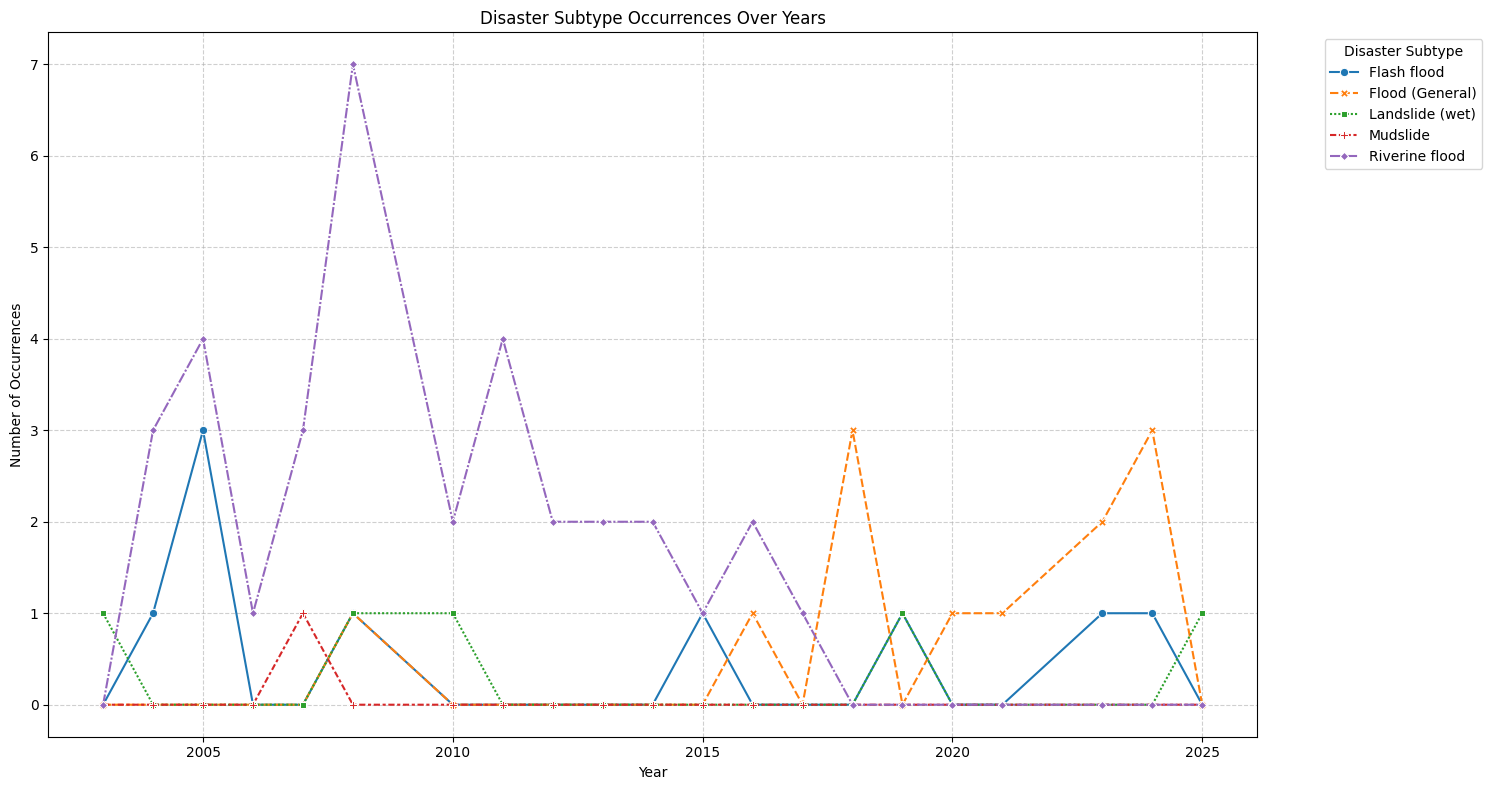

In [ ]:
## visualization of the disaster type vs years
import matplotlib.pyplot as plt
import seaborn as sns

# Extract the year from 'Entry Date'
df['Entry Year'] = df['Entry Date'].dt.year

# Group by 'Entry Year' and 'Disaster Subtype' to count occurrences
disaster_counts_by_year = df.groupby(['Entry Year', 'Disaster Subtype']).size().unstack(fill_value=0)

# Plot the trends
plt.figure(figsize=(15, 8))
sns.lineplot(data=disaster_counts_by_year, markers=True)
plt.title('Disaster Subtype Occurrences Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Occurrences')
plt.legend(title='Disaster Subtype', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Task
Aggregate disaster impact metrics by 'Disaster Subtype' using the `df` DataFrame. Calculate the sum of 'Total Deaths', 'No. Injured', 'No. Affected', and 'No. Homeless' for each subtype, filling any missing values in these impact columns with 0 before summing.

## Aggregate Impact Metrics by Disaster Subtype

### Subtask:
Group the DataFrame by 'Disaster Subtype' and calculate the sum of 'Total Deaths', 'No. Injured', 'No. Affected', and 'No. Homeless' for each subtype. Handle any missing values in these columns appropriately (e.g., fill with 0 before summing).


**Reasoning**:
To fulfill the subtask, I will select the specified columns, fill missing values with 0, and then group the DataFrame by 'Disaster Subtype' to sum the impact metrics.



In [ ]:
columns_to_aggregate = ['Disaster Subtype', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless']
disaster_impact = df[columns_to_aggregate].fillna(0).groupby('Disaster Subtype').sum()
disaster_impact

,Total Deaths,No. Injured,No. Affected,No. Homeless
Disaster Subtype,,,,
Flash flood,481.0,188.0,608859.0,0.0
Flood (General),719.0,306.0,2195170.0,0.0
Landslide (wet),184.0,29.0,6318.0,120.0
Mudslide,20.0,6.0,0.0,0.0
Riverine flood,1102.0,102.0,2225120.0,6000.0


## Visualize Top Disaster Subtypes by Total Deaths

### Subtask:
Create a bar chart to visualize the top disaster subtypes based on the 'Total Deaths' metric. Ensure the chart is clearly labeled and includes a legend.


/tmp/ipykernel_475/4199831880.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disaster_impact_sorted.index, y=disaster_impact_sorted['Total Deaths'], palette='viridis')


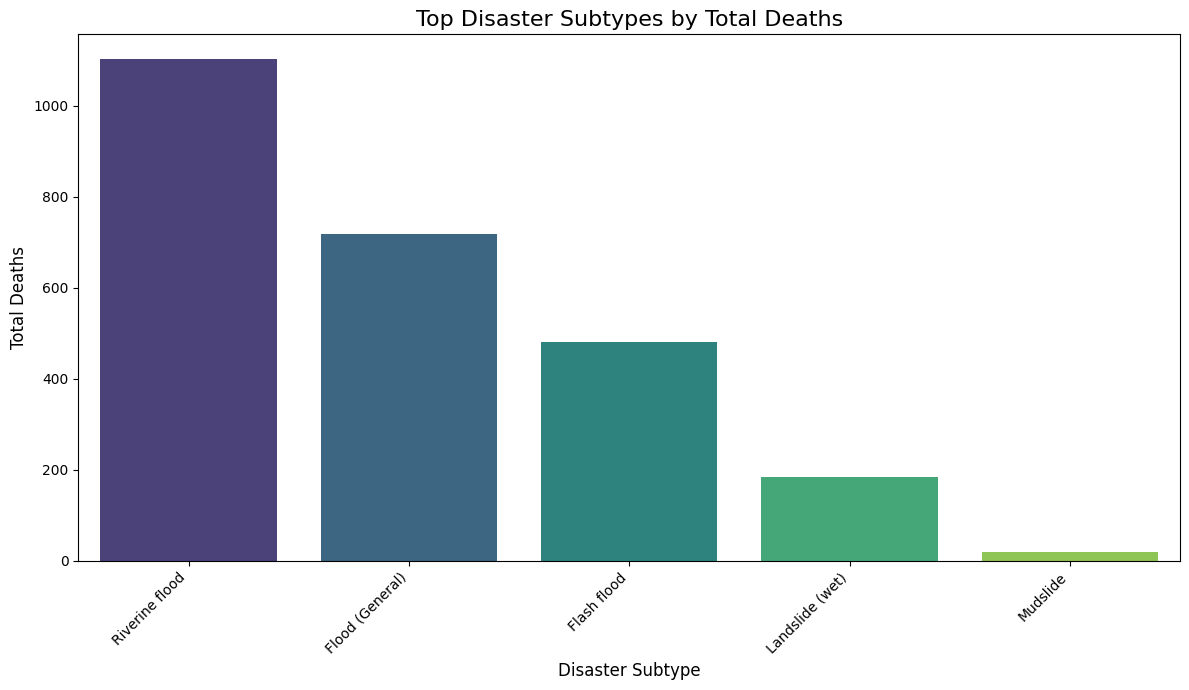

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the disaster_impact DataFrame by 'Total Deaths' in descending order
disaster_impact_sorted = disaster_impact.sort_values(by='Total Deaths', ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=disaster_impact_sorted.index, y=disaster_impact_sorted['Total Deaths'], palette='viridis')

# Set the title and labels
plt.title('Top Disaster Subtypes by Total Deaths', fontsize=16)
plt.xlabel('Disaster Subtype', fontsize=12)
plt.ylabel('Total Deaths', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

## Visualize Top Disaster Subtypes by Total Affected

### Subtask:
Create a bar chart to visualize the top disaster subtypes based on the 'Total Affected' metric. Ensure the chart is clearly labeled and includes a legend.


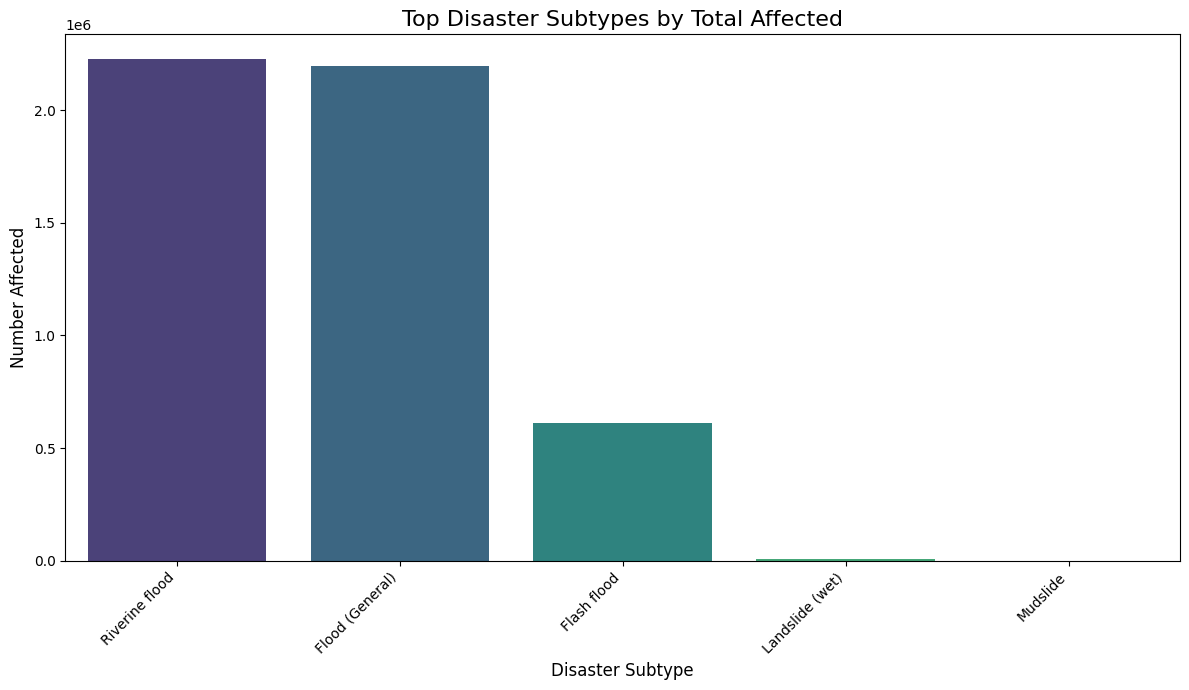

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the disaster_impact DataFrame by 'No. Affected' in descending order
disaster_impact_affected_sorted = disaster_impact.sort_values(by='No. Affected', ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=disaster_impact_affected_sorted.index, y=disaster_impact_affected_sorted['No. Affected'], hue=disaster_impact_affected_sorted.index, palette='viridis', legend=False)

# Set the title and labels
plt.title('Top Disaster Subtypes by Total Affected', fontsize=16)
plt.xlabel('Disaster Subtype', fontsize=12)
plt.ylabel('Number Affected', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

## Visualize Top Disaster Subtypes by No. Injured

### Subtask:
Create a bar chart to visualize the top disaster subtypes based on the 'No. Injured' metric. Ensure the chart is clearly labeled and includes a legend.


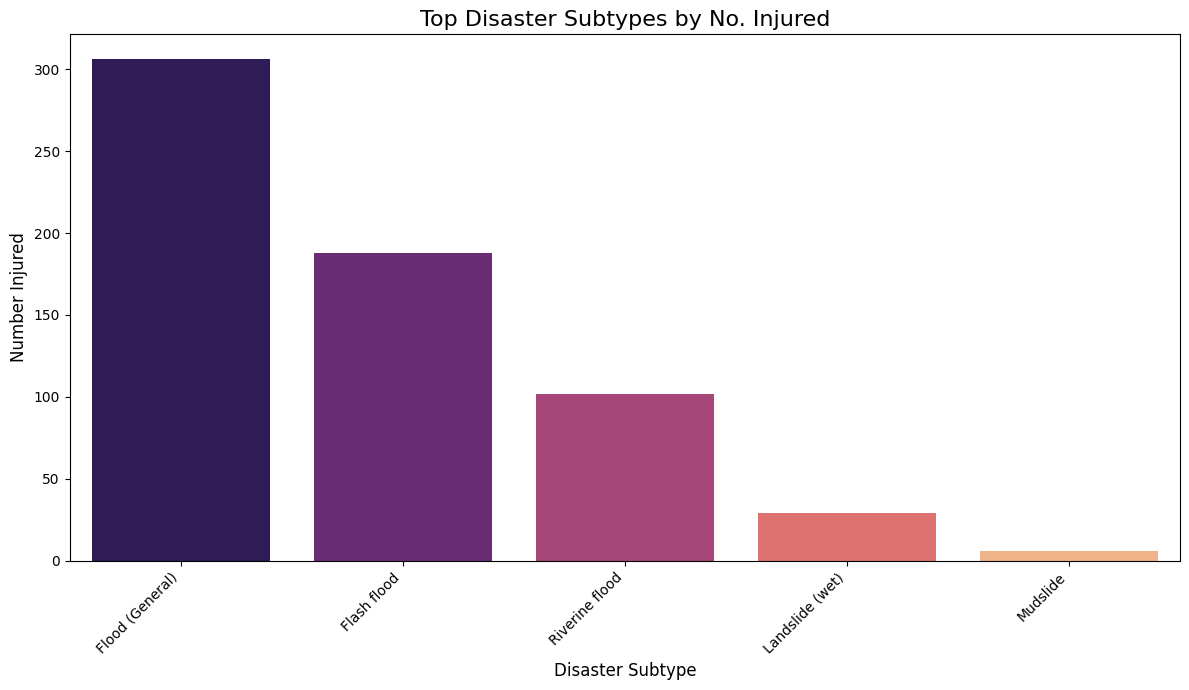

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the disaster_impact DataFrame by 'No. Injured' in descending order
disaster_impact_injured_sorted = disaster_impact.sort_values(by='No. Injured', ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=disaster_impact_injured_sorted.index, y=disaster_impact_injured_sorted['No. Injured'], hue=disaster_impact_injured_sorted.index, palette='magma', legend=False)

# Set the title and labels
plt.title('Top Disaster Subtypes by No. Injured', fontsize=16)
plt.xlabel('Disaster Subtype', fontsize=12)
plt.ylabel('Number Injured', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

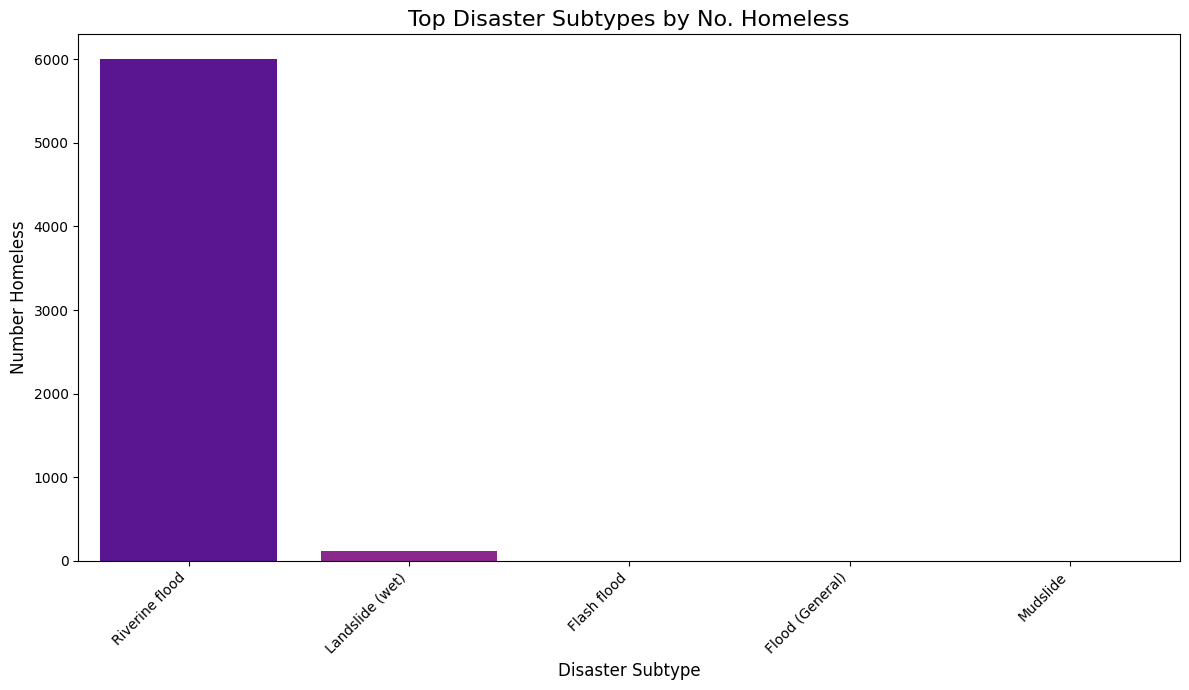

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the disaster_impact DataFrame by 'No. Homeless' in descending order
disaster_impact_homeless_sorted = disaster_impact.sort_values(by='No. Homeless', ascending=False)

# Create a bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x=disaster_impact_homeless_sorted.index, y=disaster_impact_homeless_sorted['No. Homeless'], hue=disaster_impact_homeless_sorted.index, palette='plasma', legend=False)

# Set the title and labels
plt.title('Top Disaster Subtypes by No. Homeless', fontsize=16)
plt.xlabel('Disaster Subtype', fontsize=12)
plt.ylabel('Number Homeless', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

## Map the data onto kenyan map


In [ ]:
## Filter data for valid coordinates
coord_data = df[df['Latitude'].notna() & df['Longitude'].notna()]
coord_data

,DisNo.,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,Latitude,Longitude,River Basin,...,No. Homeless,Total Affected,Total Affected,CPI,Entry Date,Last Update,Start Date,End Date,Duration,Entry Year
5,2007-0408-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,0.880000,34.280,"Kenya-Nzoia, Sabwani, Malakisi, Malaba",...,NaN,40000.0,40000.0,66.098103,2008-08-04,2025-06-25,2007-08-15,2007-10-31,-77,2008
21,2012-0166-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-0.191962,35.190,NaN,...,NaN,280670.0,280670.0,73.191592,2012-07-05,2025-12-20,2012-04-20,2012-05-16,-26,2012
22,2013-0281-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,1.660760,35.210,Braingo lake,...,NaN,5000.0,5000.0,74.263729,2013-11-27,2025-12-20,2013-08-05,2013-08-07,-2,2013
23,2013-0123-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,2.461740,36.720,Nzoia river,...,NaN,100020.0,100020.0,74.263729,2013-11-19,2025-12-20,2013-03-10,2013-04-30,-51,2013
24,2015-0564-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-2.036000,39.513,"Garissa, Tana, Nyando, Kilifi, Nzoia rivers",...,NaN,240799.0,240799.0,75.557977,2016-01-12,2025-12-20,2015-12-01,2016-01-06,-36,2016
25,2017-0205-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-2.879000,37.880,NaN,...,NaN,25000.0,25000.0,78.141002,2017-06-26,2025-12-20,2017-05-08,2017-05-16,-8,2017
29,2007-0177-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-3.590000,39.760,"Mwakuhenga, Mkuru",...,NaN,651.0,651.0,66.098103,2008-08-04,2025-12-20,2007-05-15,2007-06-11,-27,2008
30,2007-0613-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-3.610000,38.690,NaN,...,NaN,2000.0,2000.0,66.098103,2008-01-01,2025-12-20,2007-12-12,2007-12-15,-3,2008
32,2008-0518-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,0.050000,35.120,Nzoia river,...,NaN,30770.0,30770.0,68.635672,2008-11-26,2025-12-20,2008-11-10,2008-11-25,-15,2008
33,2015-0159-KEN,No,nat-hyd-flo-riv,Natural,Hydrological,Flood,Riverine flood,-0.795000,36.250,NaN,...,NaN,3000.0,3000.0,75.557977,2015-05-19,2025-12-20,2015-04-27,2015-05-02,-5,2015


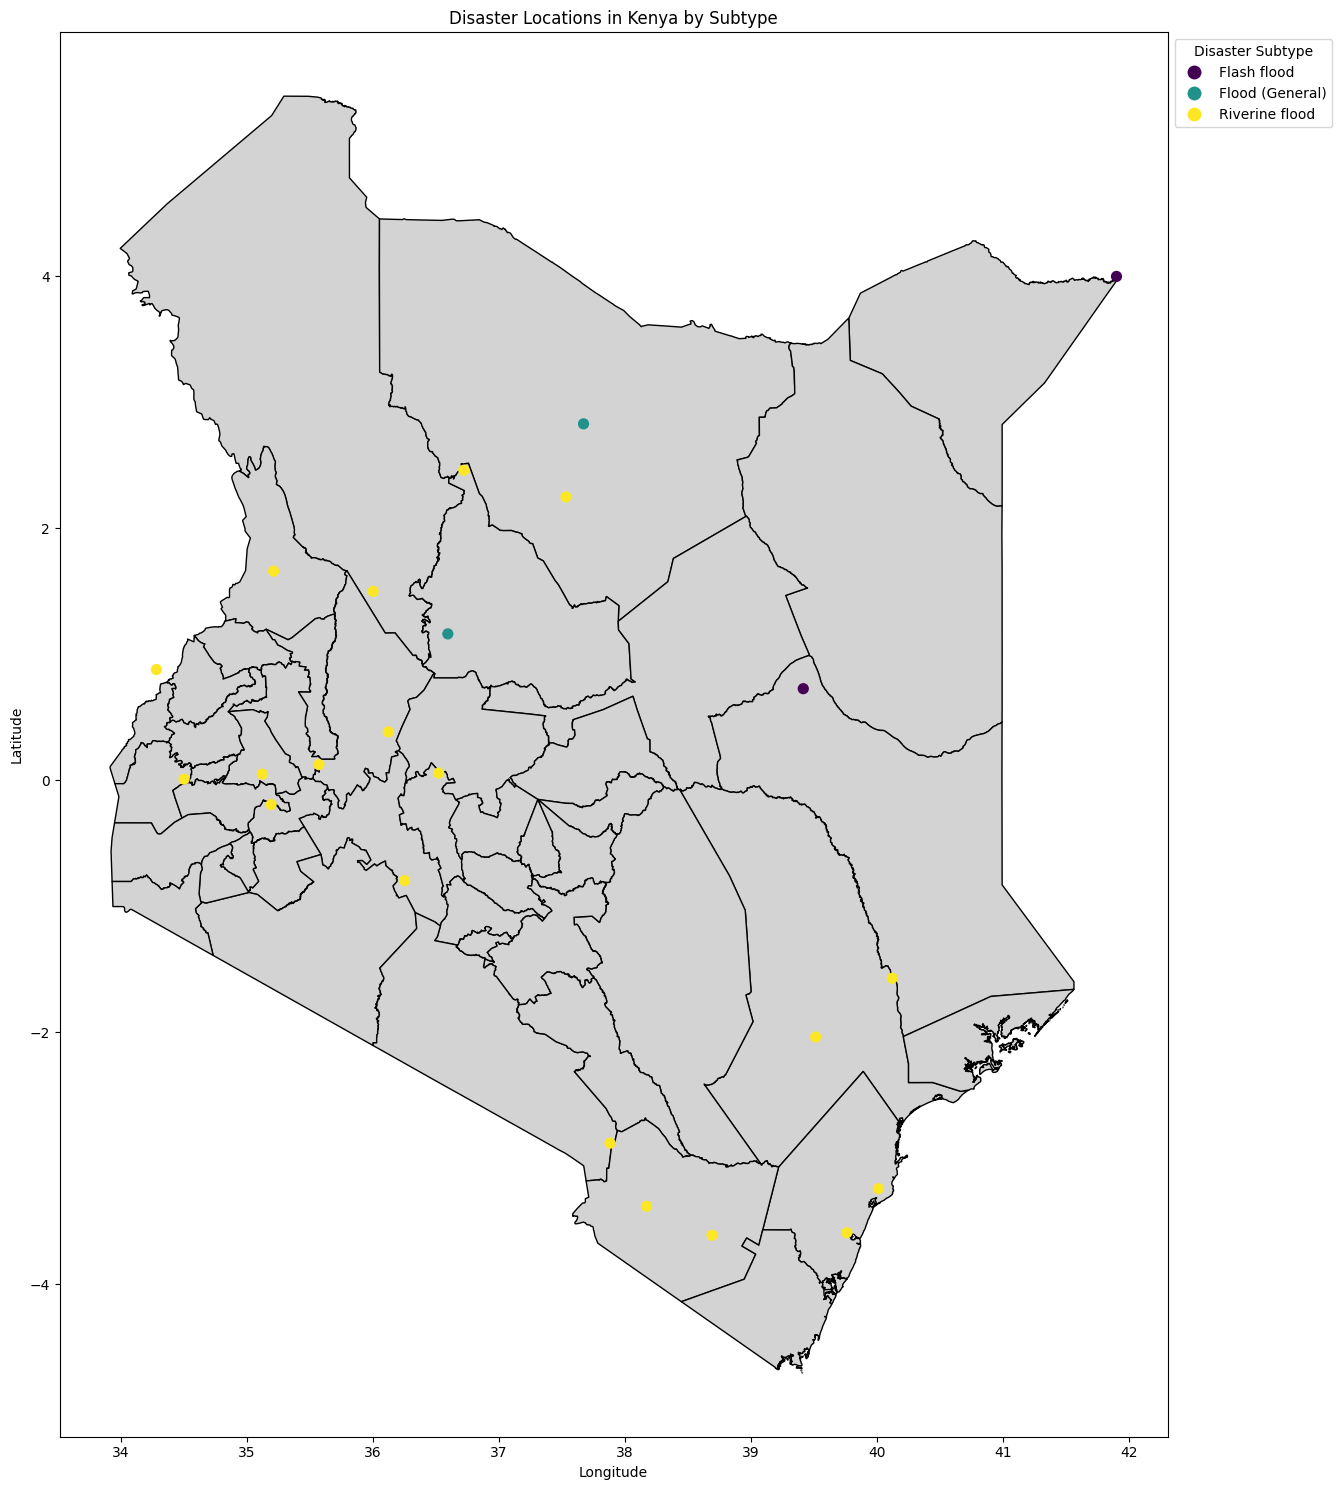

In [ ]:
# Ensure the kenya_map CRS is defined before using it
if kenya_map.crs is None:
    print("Warning: kenya_map CRS is not defined. Assuming WGS84 (EPSG:4326).")
    kenya_map = kenya_map.set_crs('EPSG:4326', allow_override=True)

# Create a GeoDataFrame from coord_data
geometry = gpd.points_from_xy(coord_data['Longitude'], coord_data['Latitude'])
coord_data_gdf = gpd.GeoDataFrame(coord_data, geometry=geometry, crs=kenya_map.crs)

# Plot the Kenya map
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
kenya_map.plot(ax=ax, color='lightgrey', edgecolor='black')

# Overlay the disaster locations, coloring by 'Disaster Subtype'
# Only plot if there is actual coordinate data
if not coord_data_gdf.empty:
    coord_data_gdf.plot(
        ax=ax,
        marker='o',
        column='Disaster Subtype',
        cmap='viridis', # Use a colormap to differentiate subtypes
        markersize=50,
        legend=True,
        legend_kwds={'loc': 'upper left', 'bbox_to_anchor': (1, 1), 'title': 'Disaster Subtype'}
    )

ax.set_title('Disaster Locations in Kenya by Subtype')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.show()

## Second dataset
Getting data from a second site to try and integrate with the EMData dataset. We are trying